In [1]:
import sys
import os
import matplotlib.pyplot as plt
# Add the project root to the Python path
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from crater_analysis.io import read_crater_locations, read_dem
from crater_analysis.analysis import filter_craters, get_crater_profile, get_dem_snippet
from crater_analysis.plotting import plot_dem, plot_crater_locations
from crater_analysis.core import Crater


dem, metadata = read_dem('../data/dems/LDEM_60S_120M.JP2')

Successfully read DEM from ../data/dems/LDEM_60S_120M.JP2


In [2]:
#lat = 'LAT_CIRC_IMG'
#lon = 'LON_CIRC_IMG'
#diam = 'DIAM_CIRC_IMG'
lat = 'lat'
lon = 'lon'
diam = 'diameter_m'
depth = 'depth_m'

#craters = read_crater_locations('../data/catalogs/lunar_crater_database_robbins_2018.csv')
#craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=None, diam_min=8, diam_max=None, lat_col=lat, diam_col=diam)

craters = read_crater_locations('../data/catalogs/moon_data.csv')
craters = filter_craters(craters, pole='south', lat_threshold=60, circ_threshold=0.85, diam_min=8000, diam_max=None, lat_col=lat, diam_col=diam)

craters.head()

Successfully read 11228 crater locations from ../data/catalogs/moon_data.csv
Filtered to 367 craters matching criteria.


,lat,lon,depth_m,diameter_m,dD,pf_slope,ef_slope,circ,test
12,-88.761,52.974,764.07,8069.7,0.094684,0.177050,0.122570,0.86749,0
20,-88.460,57.950,1017.30,8117.6,0.125320,0.205210,0.271940,0.95920,0
28,-88.190,-54.040,912.51,9030.9,0.101040,0.113860,0.125180,0.94855,0
93,-87.140,125.730,685.76,8820.2,0.077749,0.086885,0.048721,0.85129,0
103,-86.950,153.830,523.06,8306.8,0.062968,0.055629,0.075742,0.86107,0


In [3]:
### Initialise Craters ###
# Create an empty list to hold the Crater objects
crater_objects = []

# Loop through the first few rows of the DataFrame for demonstration
# To process all craters, change `craters.head(1).iterrows()` to `craters.iterrows()`
for index, row in craters.head(100).iterrows():
    # Extract crater properties from the row
    crater_id = None #row['CRATER_ID']
    crater_lon = row[lon]
    crater_lat = row[lat]
    crater_diam_km = row[diam] /1000.0  # Convert diameter from meters to kilometers
    crater_depth_m = row[depth]
    
    # Get the DEM snippet for this crater
    dem_snippet, snippet_meta, center_coords = get_dem_snippet(
        dem,
        metadata,
        crater_lon,
        crater_lat,
        crater_diam_km,
        padding_factor=1.5
    )
    
    # Create the Crater object
    crater_obj = Crater(
        crater_id=crater_id,
        dem_snippet=dem_snippet,
        metadata=snippet_meta,
        center_coords=center_coords,
        global_coords={'lon': crater_lon, 'lat': crater_lat},
    )
    
    crater_obj.add_property('diameter_km', crater_diam_km)
    crater_obj.add_property('depth_m', crater_depth_m)

    # Add the new object to our list
    crater_objects.append(crater_obj)

# Print a summary to confirm it worked
print(f"Successfully initialized {len(crater_objects)} Crater objects.")
if crater_objects:
    print("First crater object in the list:")
    print(crater_objects[50])
    print(crater_objects[50].dem_data)
print(dem)

Successfully initialized 100 Crater objects.
First crater object in the list:
Crater(id=None, center=(59.63067987807153, 59.30587713689238), global_coords={'lon': np.float64(69.742), 'lat': np.float64(-79.261)}, properties=['diameter_km', 'depth_m'])
[[-307 -221 -135 ... 3167 3206 3242]
 [-418 -315 -210 ... 3179 3227 3268]
 [-470 -387 -282 ... 3184 3241 3277]
 ...
 [  72  117  157 ... 1339 1334 1322]
 [  22   71  117 ... 1292 1288 1281]
 [ -22   26   72 ... 1250 1247 1238]]
[[ 1111  1107  1100 ...   118   127   132]
 [ 1122  1116  1108 ...   100   108   107]
 [ 1136  1128  1117 ...    72    77    77]
 ...
 [-7393 -7374 -7350 ... -2913 -2915 -2914]
 [-7407 -7387 -7361 ... -2920 -2918 -2917]
 [-7420 -7396 -7369 ... -2919 -2917 -2919]]


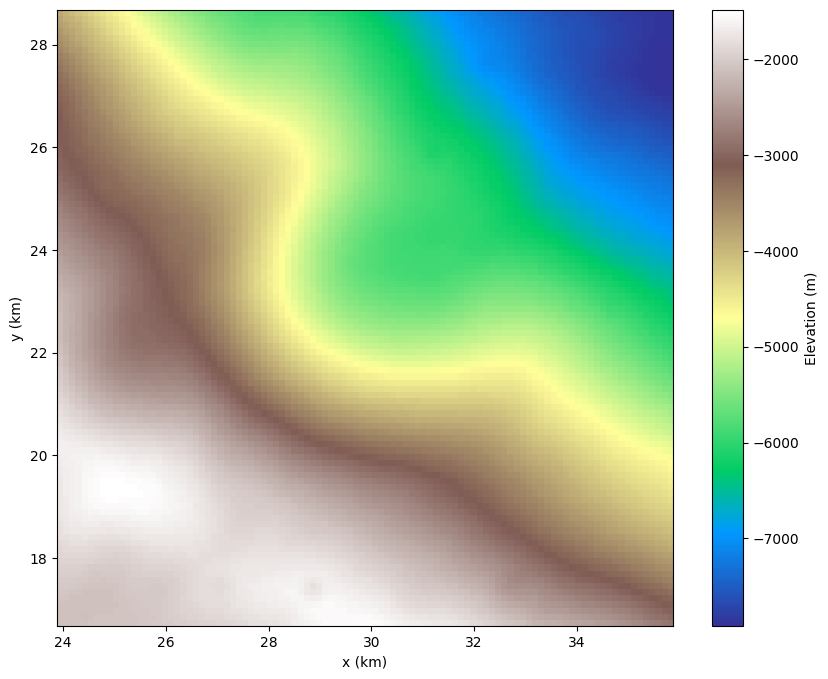

(<Figure size 1000x800 with 2 Axes>, <Axes: xlabel='x (km)', ylabel='y (km)'>)

In [4]:
plot_dem(crater_objects[0].dem_data, crater_objects[0].metadata)

## Extract a 2D Profile from a Crater

The `get_crater_profile` function uses Bresenham's line algorithm to sample actual pixel values along the profile, giving you the true DEM resolution without any interpolation.

Parameters:
- `dem_data`: The DEM array (can be the full DEM or a snippet)
- `metadata`: The corresponding metadata
- `crater_lon`, `crater_lat`: The crater's center coordinates
- `crater_diam_km`: The crater's diameter in kilometers
- `angle`: Angle of the profile in degrees (0=horizontal/E-W, 90=vertical/N-S)

Horizontal profile: 81 pixels, slope=-1456.17 m/km
Vertical profile: 82 pixels, slope=2057.00 m/km


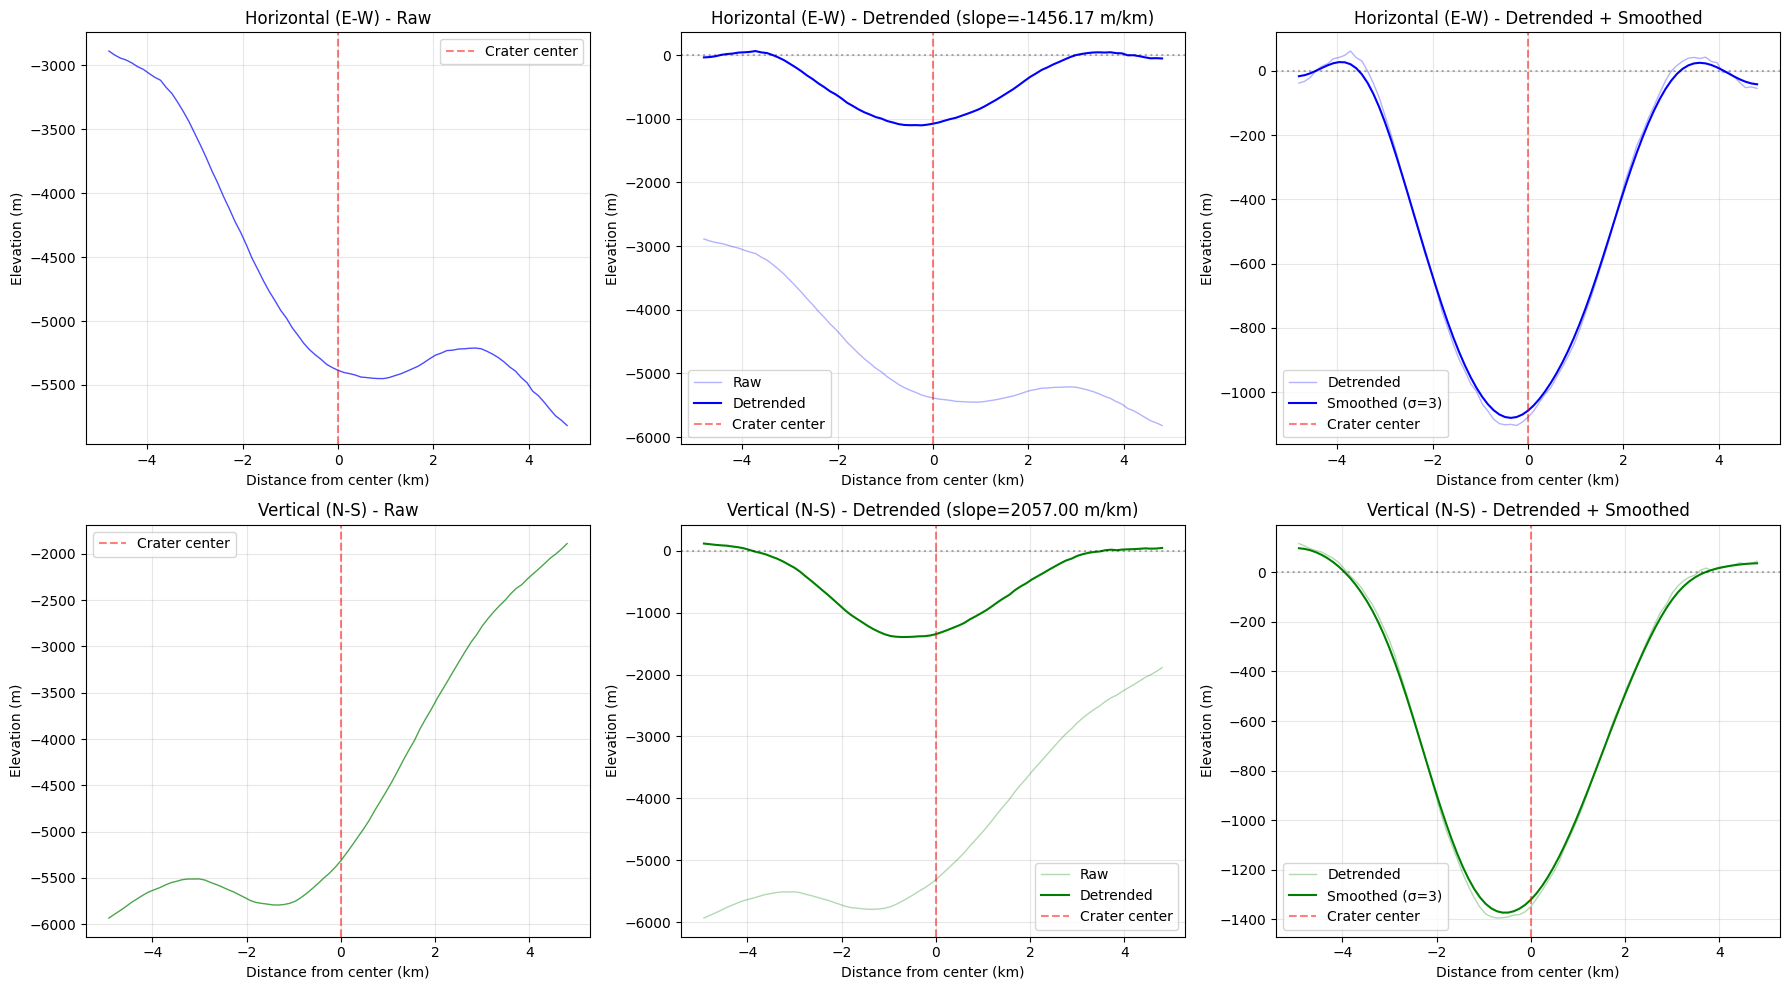

In [26]:
# Import the analysis functions
from crater_analysis.analysis import detrend_profile, smooth_profile, detrend_profile_robust

# Extract profiles in both horizontal and vertical directions
crater = crater_objects[0]

# Horizontal profile (E-W, angle=0)
distance_h, elevation_h, pixel_coords_h = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.2,
    angle=0  # 0 degrees = horizontal (E-W)
)

# Vertical profile (N-S, angle=90)
distance_v, elevation_v, pixel_coords_v = get_crater_profile(
    crater.dem_data,
    crater.metadata,
    crater.global_coords['lon'],
    crater.global_coords['lat'],
    crater_diam_km=crater.get_property('diameter_km') * 1.2,
    angle=90  # 90 degrees = vertical (N-S)
)

# Detrend the profiles first to remove regional slope
# Using robust detrending to avoid fitting the crater shape itself
elevation_h_detrended, slope_h, intercept_h = detrend_profile_robust(distance_h, elevation_h, fraction=0.2)
elevation_v_detrended, slope_v, intercept_v = detrend_profile_robust(distance_v, elevation_v, fraction=0.2)

# Then apply Gaussian smoothing to remove small-scale noise
# sigma controls the amount of smoothing (larger = more smoothing)
sigma = 3  # Try values between 1-5 depending on noise level
elevation_h_smooth = smooth_profile(elevation_h_detrended, sigma=sigma)
elevation_v_smooth = smooth_profile(elevation_v_detrended, sigma=sigma)

print(f"Horizontal profile: {len(elevation_h)} pixels, slope={slope_h:.2f} m/km")
print(f"Vertical profile: {len(elevation_v)} pixels, slope={slope_v:.2f} m/km")

# Plot raw, detrended, and smoothed profiles
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Horizontal profile - Raw
axes[0, 0].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.7)
axes[0, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title(f'Horizontal (E-W) - Raw')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal profile - Detrended
axes[0, 1].plot(distance_h, elevation_h, '-', linewidth=1, color='blue', alpha=0.3, label='Raw')
axes[0, 1].plot(distance_h, elevation_h_detrended, '-', linewidth=1.5, color='blue', label=f'Detrended')
axes[0, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Elevation (m)')
axes[0, 1].set_title(f'Horizontal (E-W) - Detrended (slope={slope_h:.2f} m/km)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Horizontal profile - Smoothed
axes[0, 2].plot(distance_h, elevation_h_detrended, '-', linewidth=1, color='blue', alpha=0.3, label='Detrended')
axes[0, 2].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label=f'Smoothed (σ={sigma})')
axes[0, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[0, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 2].set_xlabel('Distance from center (km)')
axes[0, 2].set_ylabel('Elevation (m)')
axes[0, 2].set_title(f'Horizontal (E-W) - Detrended + Smoothed')
axes[0, 2].legend()
axes[0, 2].grid(True, alpha=0.3)

# Vertical profile - Raw
axes[1, 0].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.7)
axes[1, 0].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title(f'Vertical (N-S) - Raw')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical profile - Detrended
axes[1, 1].plot(distance_v, elevation_v, '-', linewidth=1, color='green', alpha=0.3, label='Raw')
axes[1, 1].plot(distance_v, elevation_v_detrended, '-', linewidth=1.5, color='green', label=f'Detrended')
axes[1, 1].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Elevation (m)')
axes[1, 1].set_title(f'Vertical (N-S) - Detrended (slope={slope_v:.2f} m/km)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

# Vertical profile - Smoothed
axes[1, 2].plot(distance_v, elevation_v_detrended, '-', linewidth=1, color='green', alpha=0.3, label='Detrended')
axes[1, 2].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label=f'Smoothed (σ={sigma})')
axes[1, 2].axvline(x=0, color='red', linestyle='--', alpha=0.5, label='Crater center')
axes[1, 2].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 2].set_xlabel('Distance from center (km)')
axes[1, 2].set_ylabel('Elevation (m)')
axes[1, 2].set_title(f'Vertical (N-S) - Detrended + Smoothed')
axes[1, 2].legend()
axes[1, 2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile floor: distance=1.680 km, elevation=-527.92 m
Vertical profile floor: distance=1.440 km, elevation=-766.29 m


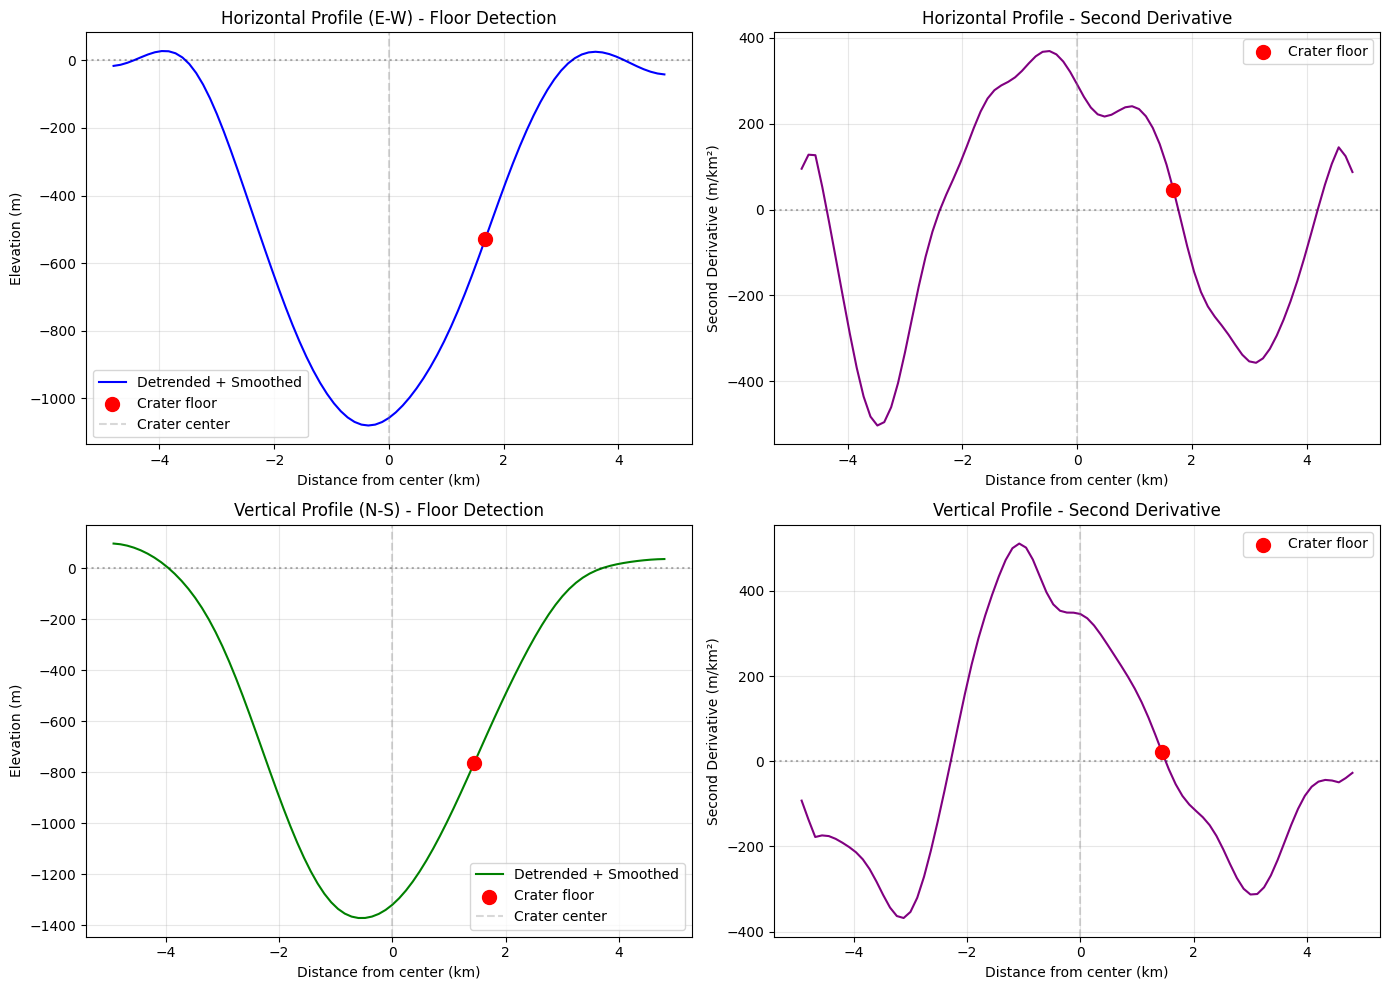

In [27]:
# Import the crater floor finding function
from crater_analysis.analysis import find_crater_floor

# Find the deepest point in the horizontal profile (using smoothed data)
floor_idx_h, floor_dist_h, floor_elev_h, second_deriv_h = find_crater_floor(distance_h, elevation_h_smooth)

# Find the deepest point in the vertical profile (using smoothed data)
floor_idx_v, floor_dist_v, floor_elev_v, second_deriv_v = find_crater_floor(distance_v, elevation_v_smooth)

print(f"Horizontal profile floor: distance={floor_dist_h:.3f} km, elevation={floor_elev_h:.2f} m")
print(f"Vertical profile floor: distance={floor_dist_v:.3f} km, elevation={floor_elev_v:.2f} m")

# Plot the profiles with the identified floor locations and second derivatives
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Horizontal profile with floor marked
axes[0, 0].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Crater floor')
axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 0].set_xlabel('Distance from center (km)')
axes[0, 0].set_ylabel('Elevation (m)')
axes[0, 0].set_title('Horizontal Profile (E-W) - Floor Detection')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Horizontal second derivative
axes[0, 1].plot(distance_h, second_deriv_h, '-', linewidth=1.5, color='purple')
axes[0, 1].scatter(floor_dist_h, second_deriv_h[floor_idx_h], color='red', s=100, zorder=5, label='Crater floor')
axes[0, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[0, 1].set_xlabel('Distance from center (km)')
axes[0, 1].set_ylabel('Second Derivative (m/km²)')
axes[0, 1].set_title('Horizontal Profile - Second Derivative')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Vertical profile with floor marked
axes[1, 0].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='green', label='Detrended + Smoothed')
axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Crater floor')
axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Crater center')
axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 0].set_xlabel('Distance from center (km)')
axes[1, 0].set_ylabel('Elevation (m)')
axes[1, 0].set_title('Vertical Profile (N-S) - Floor Detection')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Vertical second derivative
axes[1, 1].plot(distance_v, second_deriv_v, '-', linewidth=1.5, color='purple')
axes[1, 1].scatter(floor_dist_v, second_deriv_v[floor_idx_v], color='red', s=100, zorder=5, label='Crater floor')
axes[1, 1].axvline(x=0, color='gray', linestyle='--', alpha=0.3)
axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
axes[1, 1].set_xlabel('Distance from center (km)')
axes[1, 1].set_ylabel('Second Derivative (m/km²)')
axes[1, 1].set_title('Vertical Profile - Second Derivative')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Horizontal profile:
  Left rim: -3.840 km, Right rim: 3.480 km
  Measured diameter: 7.320 km
  Depth: 1103.22 m (Center elev: -1077.98 m, Avg rim elev: 25.24 m)

Vertical profile:
  Left rim: -4.680 km, Right rim: 3.960 km
  Measured diameter: 8.640 km
  Depth: 1418.78 m (Center elev: -1366.91 m, Avg rim elev: 51.87 m)

Catalog diameter: 8.070 km
Measured diameter: 7.980 km

Catalog depth: 764.07 m
Average Measured Depth: 1261.00 m
Difference (Measured - Catalog): 496.93 m


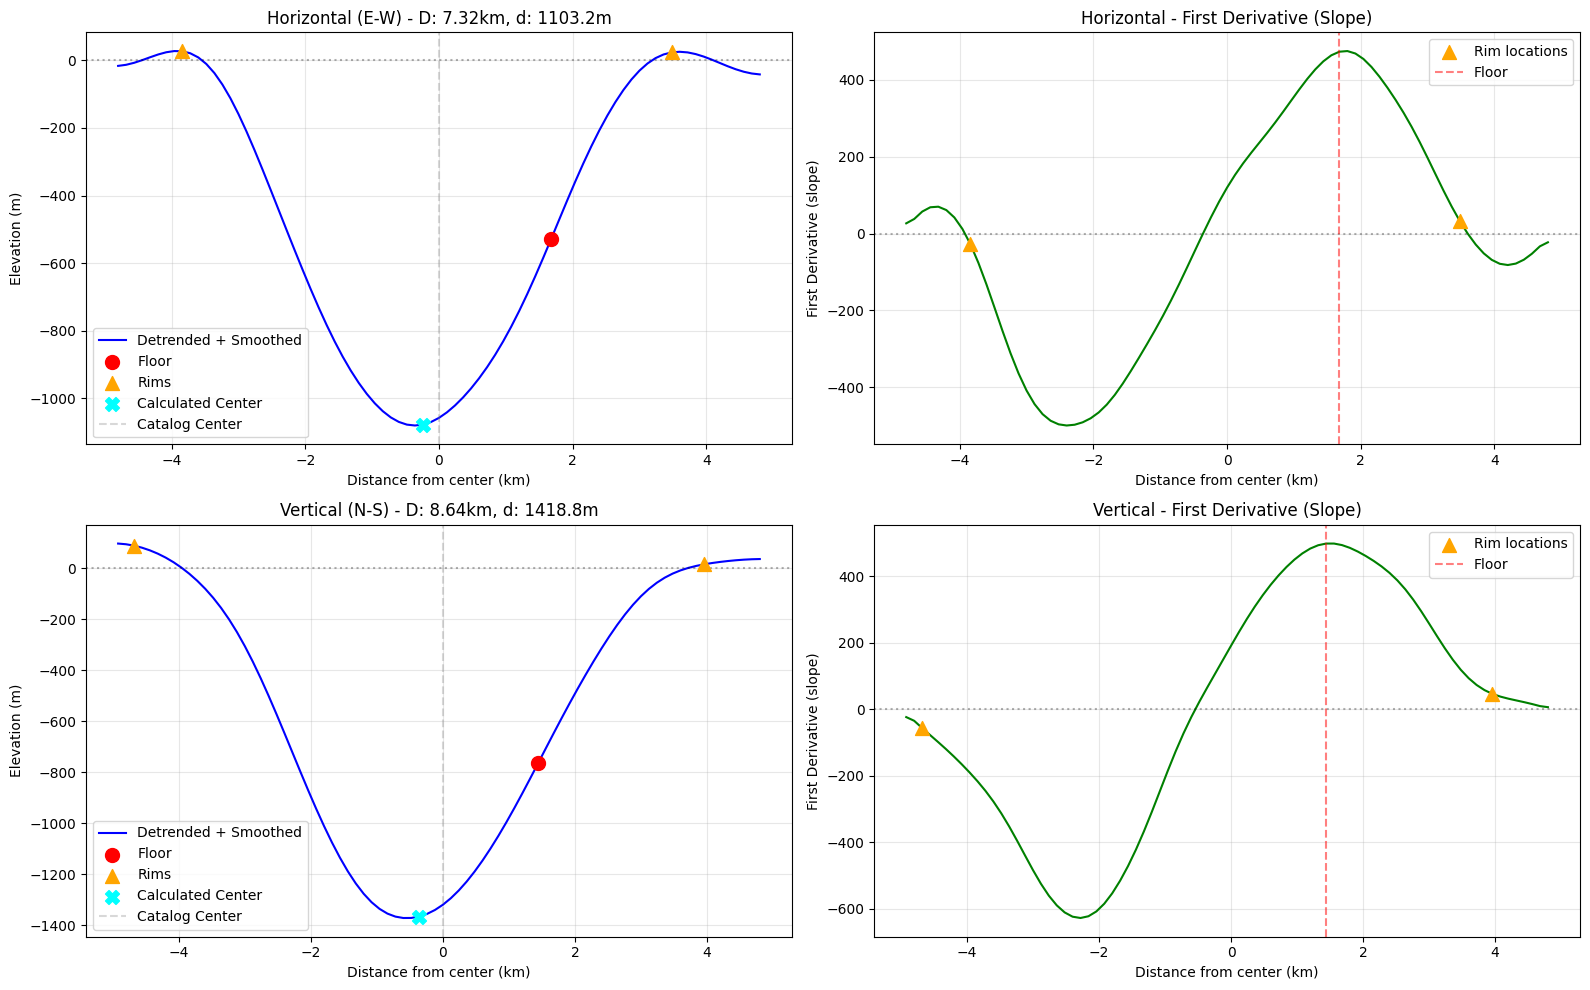

In [28]:
# Import the crater rim finding function
from crater_analysis.analysis import find_crater_rims

try:
    # Find the rims for both profiles (using smoothed data)
    left_rim_idx_h, right_rim_idx_h, left_rim_dist_h, right_rim_dist_h, first_deriv_h = find_crater_rims(
        distance_h, elevation_h_smooth, floor_idx_h, threshold_fraction=0.1
    )

    left_rim_idx_v, right_rim_idx_v, left_rim_dist_v, right_rim_dist_v, first_deriv_v = find_crater_rims(
        distance_v, elevation_v_smooth, floor_idx_v, threshold_fraction=0.1
    )

    # Calculate diameters
    diameter_h = right_rim_dist_h - left_rim_dist_h
    diameter_v = right_rim_dist_v - left_rim_dist_v

    # Calculate depth for Horizontal Profile
    # Center is the midpoint index between the two rims
    center_idx_h = (left_rim_idx_h + right_rim_idx_h) // 2
    center_dist_h = distance_h[center_idx_h]
    center_elev_h = elevation_h_smooth[center_idx_h]
    
    # Average rim elevation
    avg_rim_elev_h = (elevation_h_smooth[left_rim_idx_h] + elevation_h_smooth[right_rim_idx_h]) / 2
    
    # Depth is difference between average rim elevation and center elevation
    depth_h = avg_rim_elev_h - center_elev_h

    # Calculate depth for Vertical Profile
    center_idx_v = (left_rim_idx_v + right_rim_idx_v) // 2
    center_dist_v = distance_v[center_idx_v]
    center_elev_v = elevation_v_smooth[center_idx_v]
    
    avg_rim_elev_v = (elevation_v_smooth[left_rim_idx_v] + elevation_v_smooth[right_rim_idx_v]) / 2
    depth_v = avg_rim_elev_v - center_elev_v

    # Average Depth across both profiles
    avg_depth = (depth_h + depth_v) / 2
    
    # Get catalog depth
    catalog_depth = crater.get_property('depth_m')

    print(f"Horizontal profile:")
    print(f"  Left rim: {left_rim_dist_h:.3f} km, Right rim: {right_rim_dist_h:.3f} km")
    print(f"  Measured diameter: {diameter_h:.3f} km")
    print(f"  Depth: {depth_h:.2f} m (Center elev: {center_elev_h:.2f} m, Avg rim elev: {avg_rim_elev_h:.2f} m)")
    
    print(f"\nVertical profile:")
    print(f"  Left rim: {left_rim_dist_v:.3f} km, Right rim: {right_rim_dist_v:.3f} km")
    print(f"  Measured diameter: {diameter_v:.3f} km")
    print(f"  Depth: {depth_v:.2f} m (Center elev: {center_elev_v:.2f} m, Avg rim elev: {avg_rim_elev_v:.2f} m)")

    print(f"\nCatalog diameter: {crater.get_property('diameter_km'):.3f} km")
    print(f"Measured diameter: {(diameter_h + diameter_v) / 2:.3f} km")
    
    print(f"\nCatalog depth: {catalog_depth:.2f} m")
    print(f"Average Measured Depth: {avg_depth:.2f} m")
    print(f"Difference (Measured - Catalog): {avg_depth - catalog_depth:.2f} m")

    # Plot the profiles with floor and rims marked
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    # Horizontal profile with rims
    axes[0, 0].plot(distance_h, elevation_h_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
    axes[0, 0].scatter(floor_dist_h, floor_elev_h, color='red', s=100, zorder=5, label='Floor')
    axes[0, 0].scatter([left_rim_dist_h, right_rim_dist_h], 
                    [elevation_h_smooth[left_rim_idx_h], elevation_h_smooth[right_rim_idx_h]], 
                    color='orange', s=100, marker='^', zorder=5, label='Rims')
    axes[0, 0].scatter(center_dist_h, center_elev_h, color='cyan', s=100, marker='X', zorder=5, label='Calculated Center')
    
    axes[0, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Catalog Center')
    axes[0, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[0, 0].set_xlabel('Distance from center (km)')
    axes[0, 0].set_ylabel('Elevation (m)')
    axes[0, 0].set_title(f'Horizontal (E-W) - D: {diameter_h:.2f}km, d: {depth_h:.1f}m')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)

    # Horizontal first derivative
    axes[0, 1].plot(distance_h, first_deriv_h, '-', linewidth=1.5, color='green')
    axes[0, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[0, 1].scatter([left_rim_dist_h, right_rim_dist_h],
                    [first_deriv_h[left_rim_idx_h], first_deriv_h[right_rim_idx_h]],
                    color='orange', s=100, marker='^', zorder=5, label='Rim locations')
    axes[0, 1].axvline(x=floor_dist_h, color='red', linestyle='--', alpha=0.5, label='Floor')
    axes[0, 1].set_xlabel('Distance from center (km)')
    axes[0, 1].set_ylabel('First Derivative (slope)')
    axes[0, 1].set_title('Horizontal - First Derivative (Slope)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)

    # Vertical profile with rims
    axes[1, 0].plot(distance_v, elevation_v_smooth, '-', linewidth=1.5, color='blue', label='Detrended + Smoothed')
    axes[1, 0].scatter(floor_dist_v, floor_elev_v, color='red', s=100, zorder=5, label='Floor')
    axes[1, 0].scatter([left_rim_dist_v, right_rim_dist_v],
                    [elevation_v_smooth[left_rim_idx_v], elevation_v_smooth[right_rim_idx_v]],
                    color='orange', s=100, marker='^', zorder=5, label='Rims')
    axes[1, 0].scatter(center_dist_v, center_elev_v, color='cyan', s=100, marker='X', zorder=5, label='Calculated Center')

    axes[1, 0].axvline(x=0, color='gray', linestyle='--', alpha=0.3, label='Catalog Center')
    axes[1, 0].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[1, 0].set_xlabel('Distance from center (km)')
    axes[1, 0].set_ylabel('Elevation (m)')
    axes[1, 0].set_title(f'Vertical (N-S) - D: {diameter_v:.2f}km, d: {depth_v:.1f}m')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)

    # Vertical first derivative
    axes[1, 1].plot(distance_v, first_deriv_v, '-', linewidth=1.5, color='green')
    axes[1, 1].axhline(y=0, color='black', linestyle=':', alpha=0.3)
    axes[1, 1].scatter([left_rim_dist_v, right_rim_dist_v],
                    [first_deriv_v[left_rim_idx_v], first_deriv_v[right_rim_idx_v]],
                    color='orange', s=100, marker='^', zorder=5, label='Rim locations')
    axes[1, 1].axvline(x=floor_dist_v, color='red', linestyle='--', alpha=0.5, label='Floor')
    axes[1, 1].set_xlabel('Distance from center (km)')
    axes[1, 1].set_ylabel('First Derivative (slope)')
    axes[1, 1].set_title('Vertical - First Derivative (Slope)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

except ValueError as e:
    print(f"Error finding rims: {e}")
    print("Skipping plotting for this crater.")